In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [4]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [5]:
results['dataset'] = results['model_id'].apply(lambda x: x.split('_')[-5])
results = results[results['dataset'] != 'DavidEtAl'] 
results = results[results['dataset'] != 'LiuEtAl'] 
results = results[results['dataset'] != 'AllDatasets']
results = results[results['dataset'] != 'NotGeo']
results = results[results['dataset'] != 'AllDatasetsAndNotGeo']
results = results[results['dataset'] != 'LiuEtAlAndNotGeo']
results['dataset'].unique()

array(['2', '3', '1'], dtype=object)

In [6]:
config = config[config['out_domain'] == 'no']
config['dataset'].unique()

array(['2', '3', '1'], dtype=object)

In [7]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on=['experiment','dataset'], suffixes=('_results', '_config'))

In [8]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [9]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

/tmp/ipykernel_863703/952146440.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')


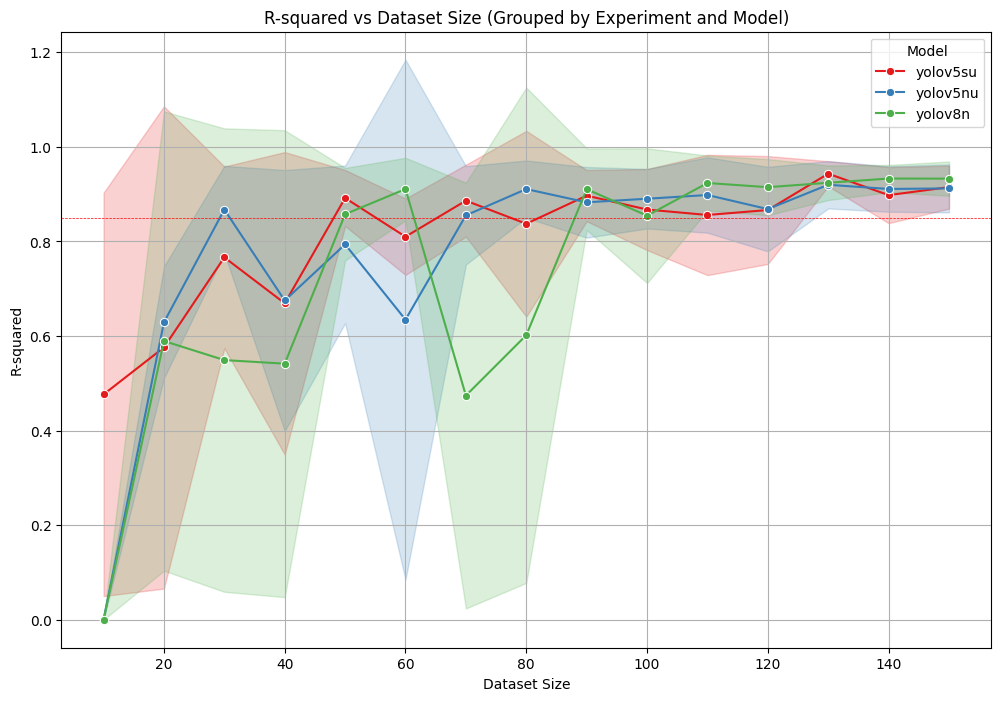

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov5nu', 'yolov5su'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

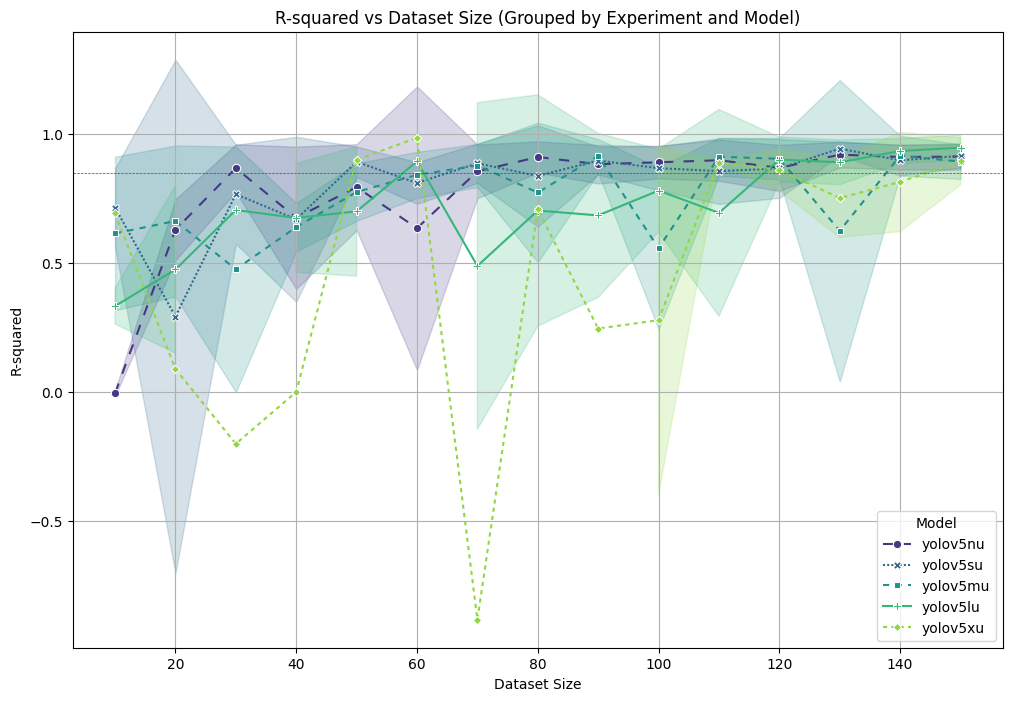

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5lu': '', 'yolov5nu': (5, 5), 'yolov5su': (1, 1), 'yolov5mu': (3, 3), 'yolov5xu': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'], style_order=['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

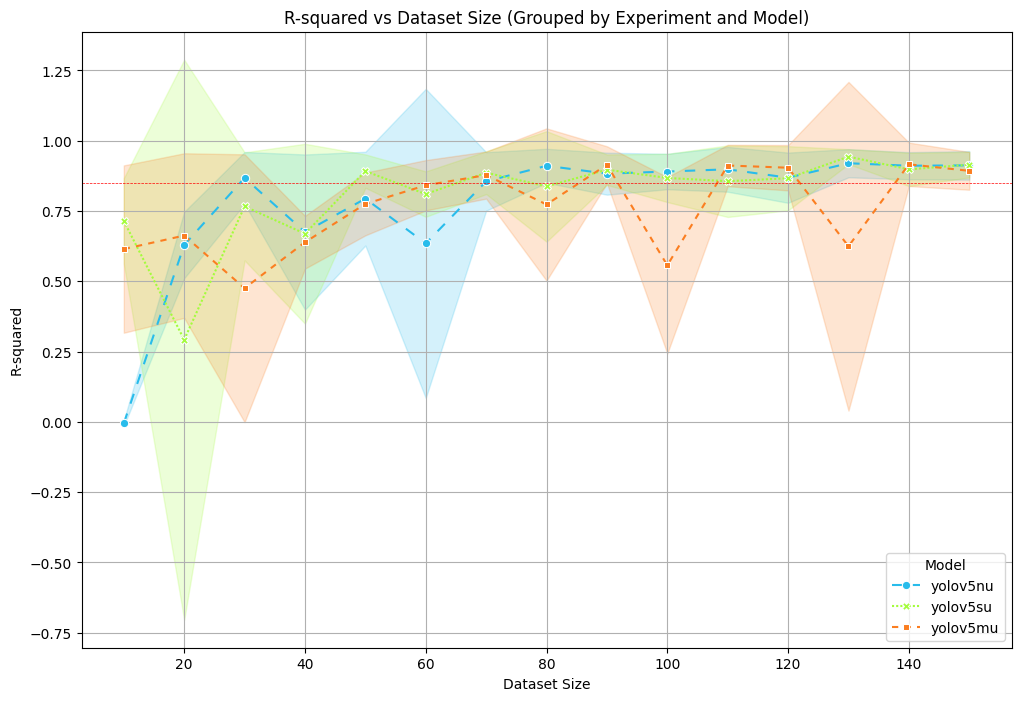

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov5nu', 'yolov5su', 'yolov5mu'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = { 'yolov5nu': (5, 5), 'yolov5su': (1, 1), 'yolov5mu': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov5nu', 'yolov5su', 'yolov5mu'], style_order=['yolov5nu', 'yolov5su', 'yolov5mu'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

177


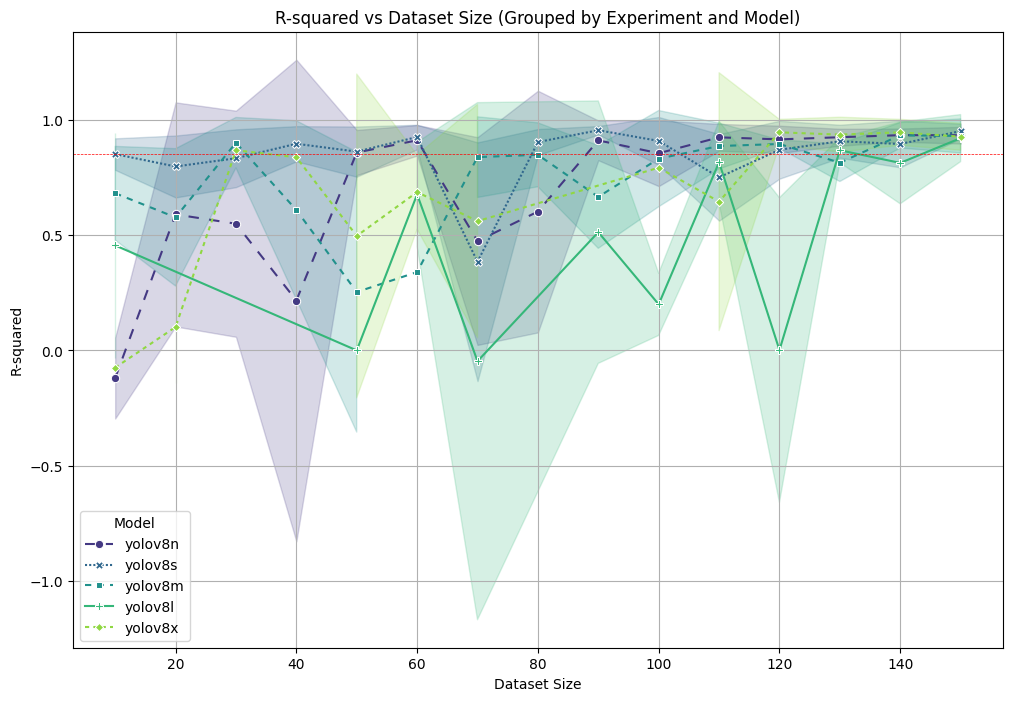

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov8n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov8l': '', 'yolov8n': (5, 5), 'yolov8s': (1, 1), 'yolov8m': (3, 3), 'yolov8x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'], style_order=['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

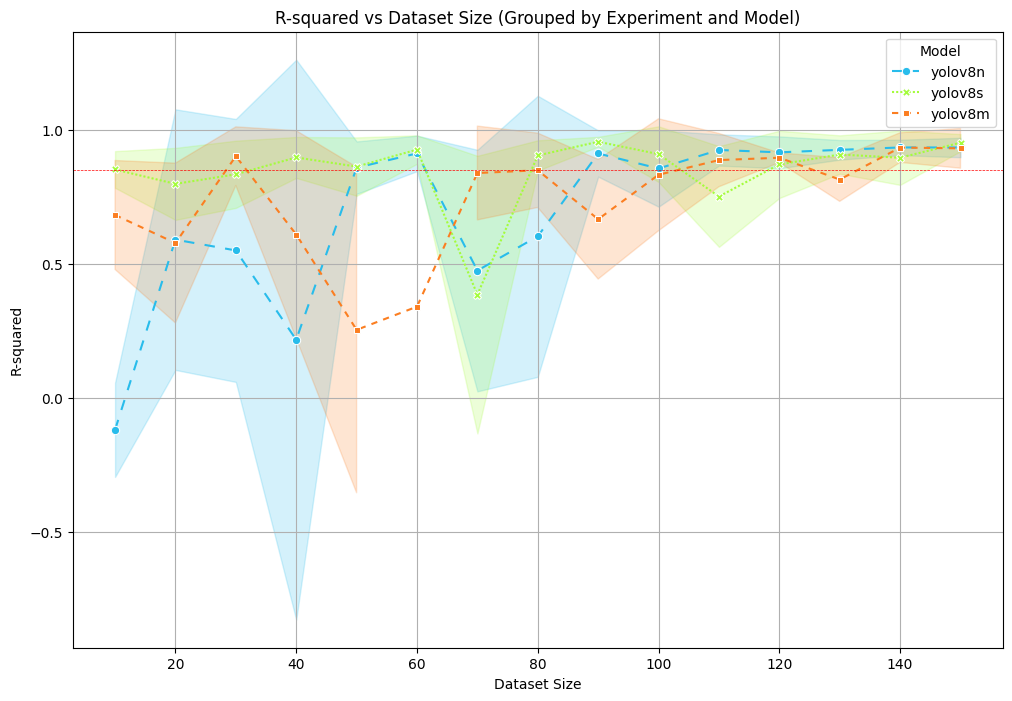

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov8n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov8s', 'yolov8m'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = {'yolov8n': (5, 5), 'yolov8s': (1, 1), 'yolov8m': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov8n', 'yolov8s', 'yolov8m'], style_order=['yolov8n', 'yolov8s', 'yolov8m'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

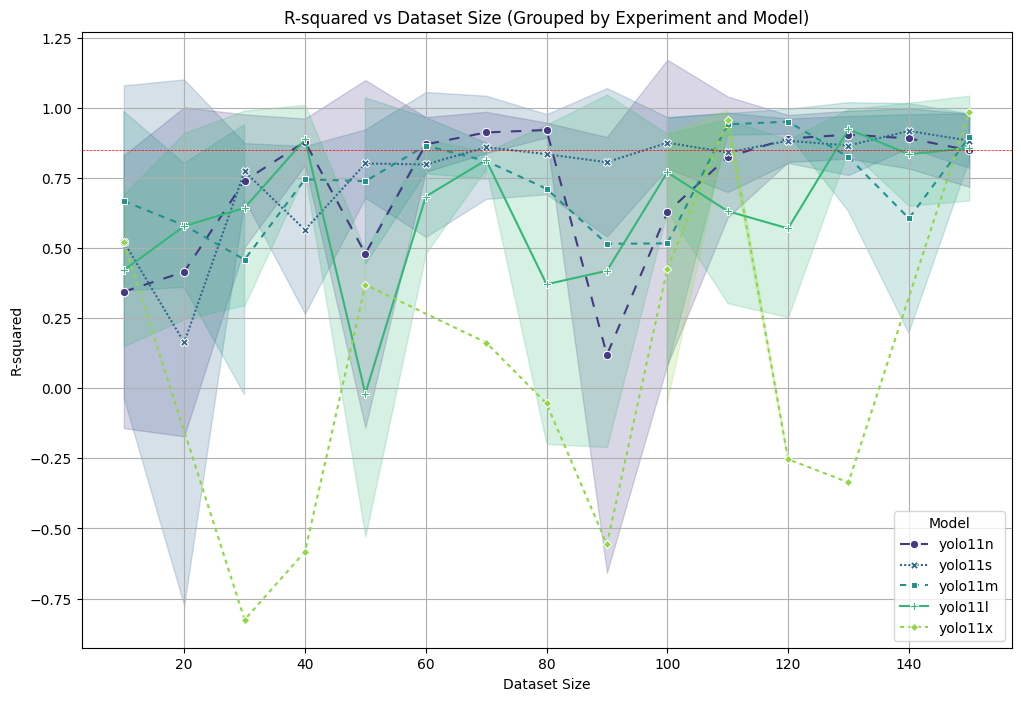

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolo11n and yolo11n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolo11l': '', 'yolo11n': (5, 5), 'yolo11s': (1, 1), 'yolo11m': (3, 3), 'yolo11x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'], style_order=['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

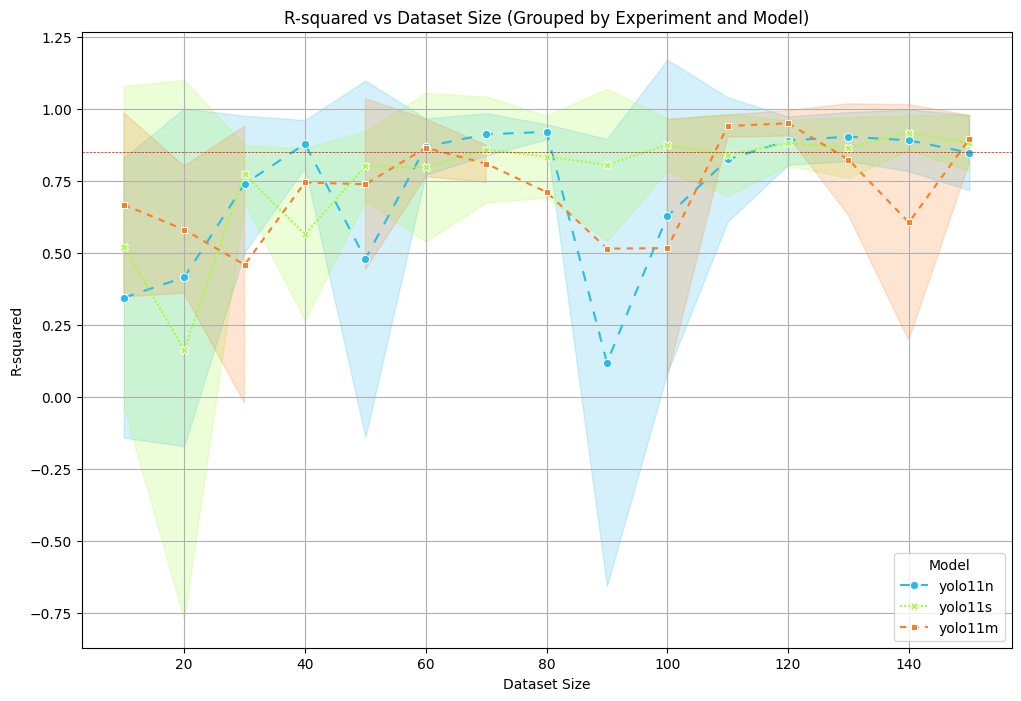

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolo11n and yolo11n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolo11n', 'yolo11s', 'yolo11m'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = {'yolo11n': (5, 5), 'yolo11s': (1, 1), 'yolo11m': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolo11n', 'yolo11s', 'yolo11m'], style_order=['yolo11n', 'yolo11s', 'yolo11m'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_29725/2899624212.py:32: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['rtdetr-l', 'rtdetr-x'], style_order=['rtdetr-l', 'rtdetr-x'])


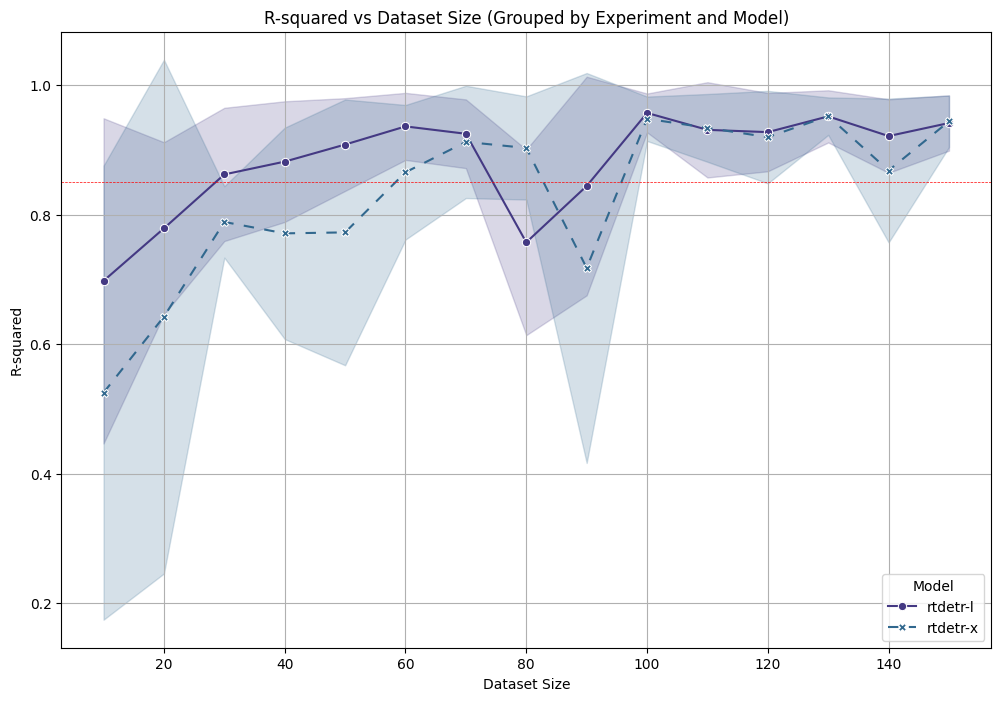

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(['rtdetr-l', 'rtdetr-x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'rtdetr-l': '', 'rtdetr-x': (5, 5)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['rtdetr-l', 'rtdetr-x'], style_order=['rtdetr-l', 'rtdetr-x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
models = ['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu']
# Initialize the filtered DataFrame
filtered_df = df.copy()
# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Select out_domain aws no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']
# Add this after the out_domain filter
# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(models)]
# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]
# Count the row per filtered_df model yolov5su dataset 1
print("Count of yolov5su dataset 1:", filtered_df[(filtered_df['model'] == 'yolov5su') & (filtered_df['dataset'] == '1')].shape[0])

Unique model values: ['yolov5su' 'yolov5nu' 'yolov8n' 'yolo11n' 'yolov5mu' 'yolov8m' 'yolo11m'
 'yolov5lu' 'yolov8l' 'yolo11l' 'yolov5xu' 'yolov8s' 'yolo11s' 'rtdetr-l'
 'rtdetr-x' 'yolov8x' 'yolo11x']
Count of yolov5su dataset 1: 15


Unique model values: ['yolov5su' 'yolov5nu' 'yolov8n' 'yolo11n' 'yolov5mu' 'yolov8m' 'yolo11m'
 'yolov5lu' 'yolov8l' 'yolo11l' 'yolov5xu' 'yolov8s' 'yolo11s' 'rtdetr-l'
 'rtdetr-x' 'yolov8x' 'yolo11x']


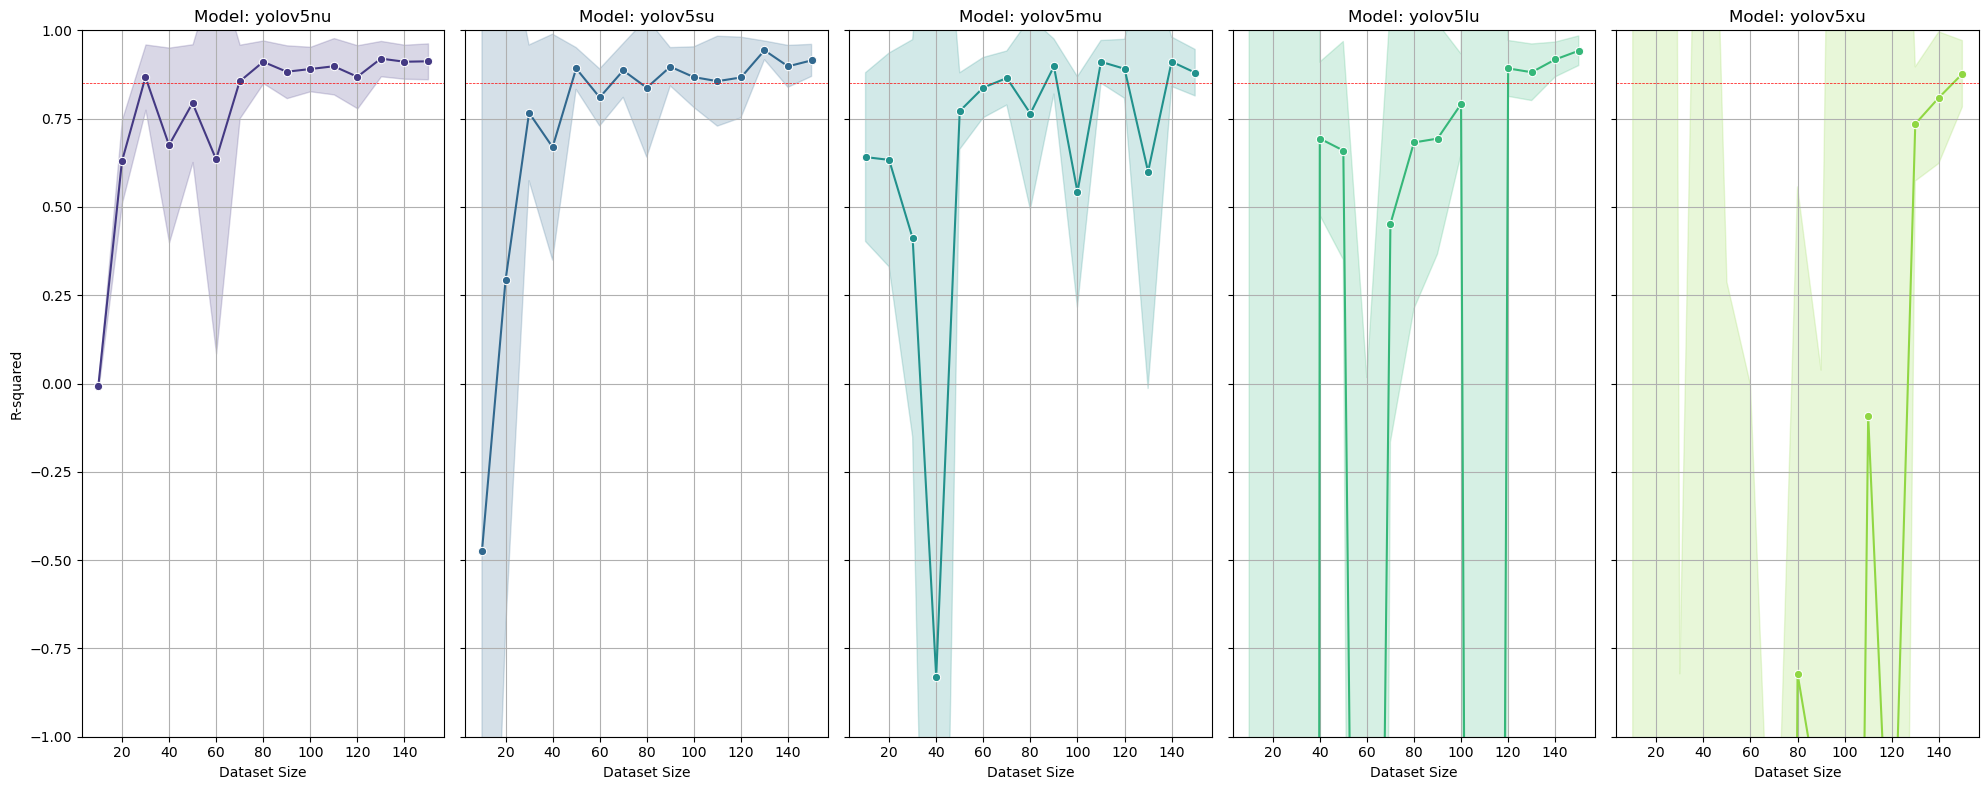

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
models = ['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu']
# Initialize the filtered DataFrame
filtered_df = df.copy()
# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Select out_domain aws no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']
# Add this after the out_domain filter
# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(models)]
# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model','dataset_size'])['r_squared'].idxmax()]
# Set r-squared <0 to 0
# filtered_df = filtered_df[filtered_df['r_squared'] >= -1]
# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']
# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')
# Define custom colors and linestyles for each model - only need 2 colors
palette = sns.color_palette("viridis", 5)  # Only 2 models
linestyles = {'yolov5nu': '', 'yolov5su': (5, 5), 'yolov5mu': (1, 1), 'yolov5lu': (3, 3), 'yolov5xu': (2, 2)}  # Update dashes to have 5 styles
# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    # Filter to single model but don't use it for hue/style
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Simple lineplot without hue/style since we're already filtered
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',  # Use marker='o' instead of markers=True
        color=palette[models.index(model)],
        ax=ax
    )
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('R-squared')
    ax.grid(True)

plt.ylim(-1, 1)
plt.tight_layout()
# plt.show()

# save as svg
plt.savefig('MDPI_template/Plots/r2_vs_dataset_size_yolov5.pdf', format='pdf')

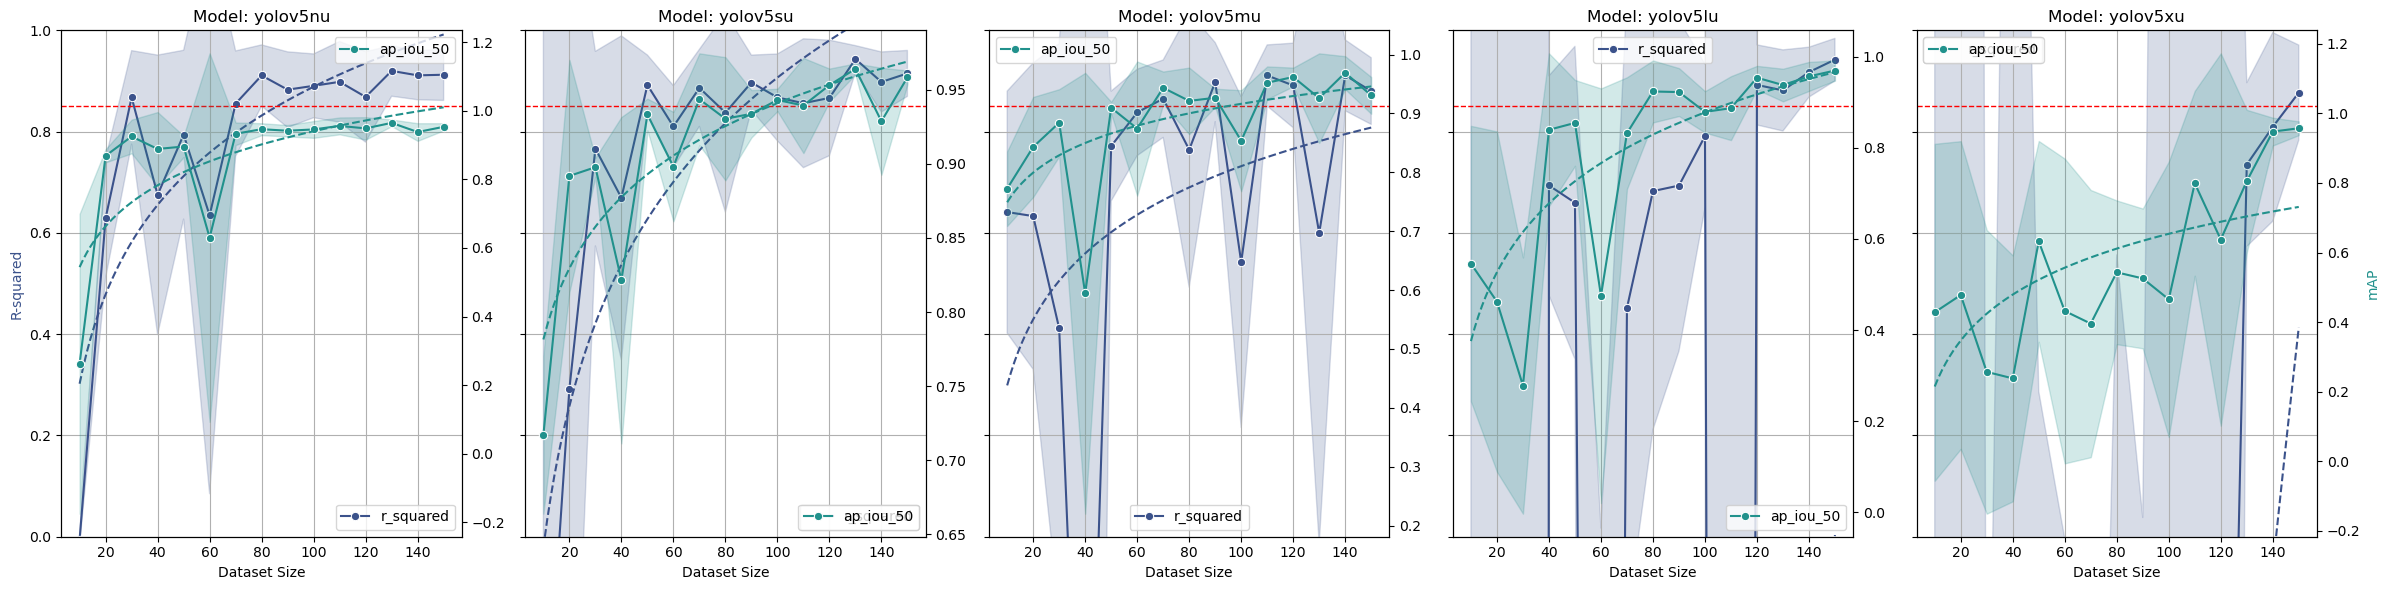

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit

models = ['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define a logarithmic function for fitting
def log_func(x, a, b):
    return a * np.log(x) + b

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='r_squared'
    )
    
    # Fit a logarithmic model to r_squared vs dataset_size
    popt_r2, _ = curve_fit(log_func, model_data['dataset_size'], model_data['r_squared'])
    x_fit = np.linspace(model_data['dataset_size'].min(), model_data['dataset_size'].max(), 100)
    y_fit_r2 = log_func(x_fit, *popt_r2)
    ax.plot(x_fit, y_fit_r2, color=metric_colors['r_squared'], linestyle='--', label='Log fit r_squared')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50_95
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='ap_iou_50'
    )
    
    # Fit a logarithmic model to ap_iou_50_95 vs dataset_size
    popt_ap, _ = curve_fit(log_func, model_data['dataset_size'], model_data['ap_iou_50'])
    y_fit_ap = log_func(x_fit, *popt_ap)
    ax2.plot(x_fit, y_fit_ap, color=metric_colors['ap_iou_50'], linestyle='--', label='Log fit ap_iou_50')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
# plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolov5.pdf', format='pdf')
plt.show()

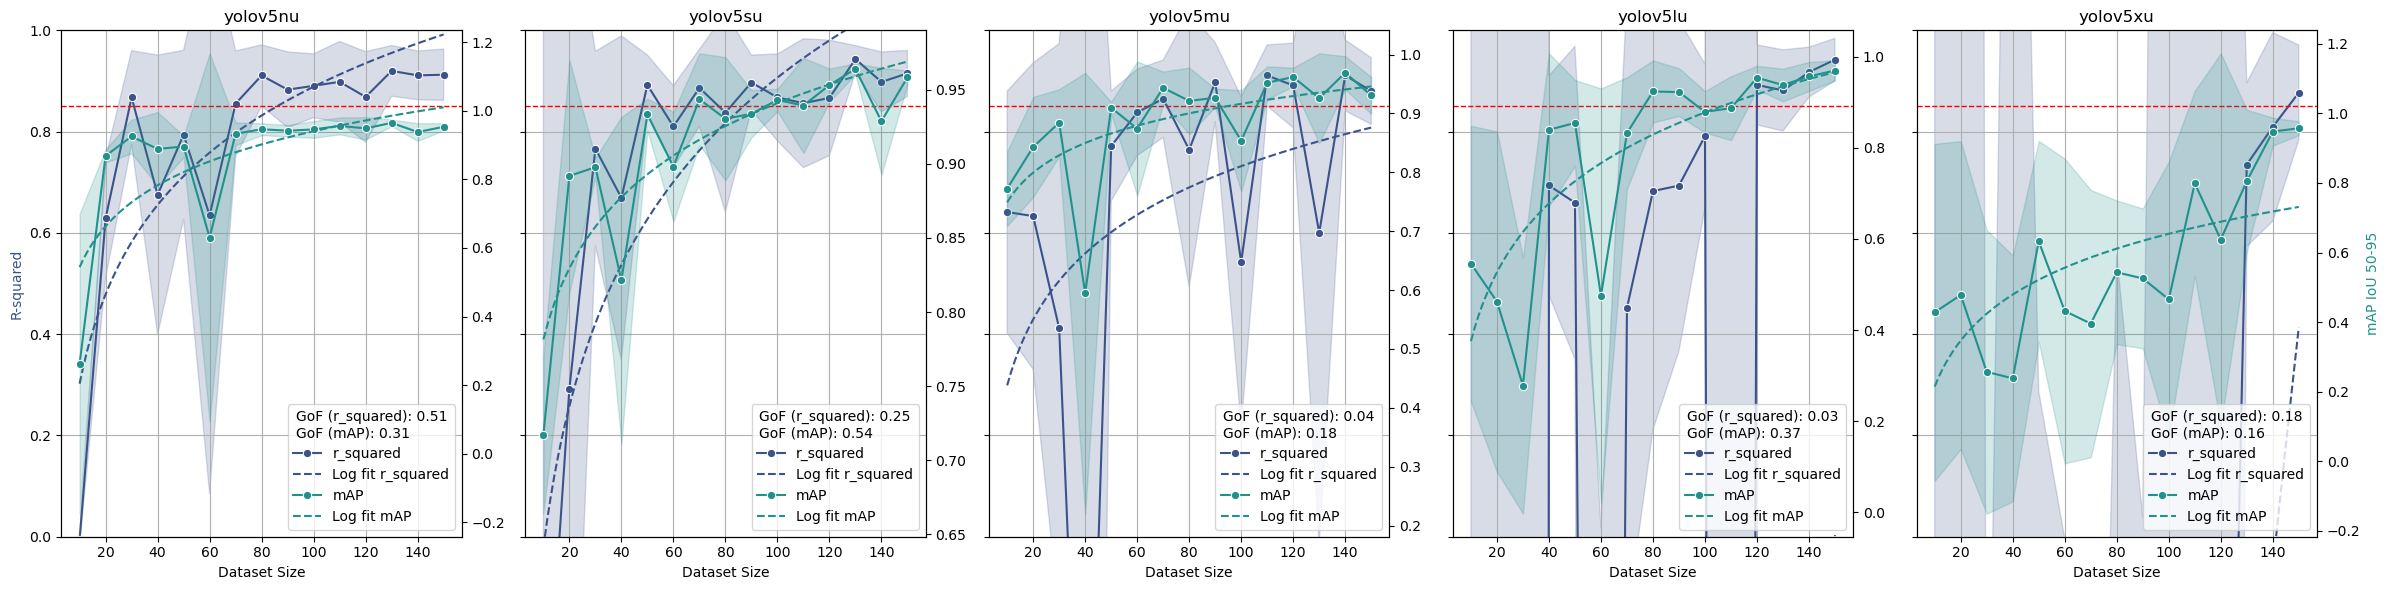

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define a logarithmic function for fitting
def log_func(x, a, b):
    return a * np.log(x) + b

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='r_squared',
        legend=False
    )
    
    # Fit a logarithmic model to r_squared vs dataset_size
    popt_r2, _ = curve_fit(log_func, model_data['dataset_size'], model_data['r_squared'])
    x_fit = np.linspace(model_data['dataset_size'].min(), model_data['dataset_size'].max(), 100)
    y_fit_r2 = log_func(x_fit, *popt_r2)
    ax.plot(x_fit, y_fit_r2, color=metric_colors['r_squared'], linestyle='--', label='Log fit r_squared')
    
    # Calculate R^2 for r_squared
    r2_r2 = r2_score(model_data['r_squared'], log_func(model_data['dataset_size'], *popt_r2))
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit a logarithmic model to ap_iou_50 vs dataset_size
    popt_ap, _ = curve_fit(log_func, model_data['dataset_size'], model_data['ap_iou_50'])
    y_fit_ap = log_func(x_fit, *popt_ap)
    ax2.plot(x_fit, y_fit_ap, color=metric_colors['ap_iou_50'], linestyle='--', label='Log fit mAP')
    
    # Calculate R^2 for ap_iou_50
    r2_ap = r2_score(model_data['ap_iou_50'], log_func(model_data['dataset_size'], *popt_ap))
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    combined_title = f'GoF (r_squared): {r2_r2:.2f}\nGoF (mAP): {r2_ap:.2f}'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolov5.pdf', format='pdf')
# plt.show()

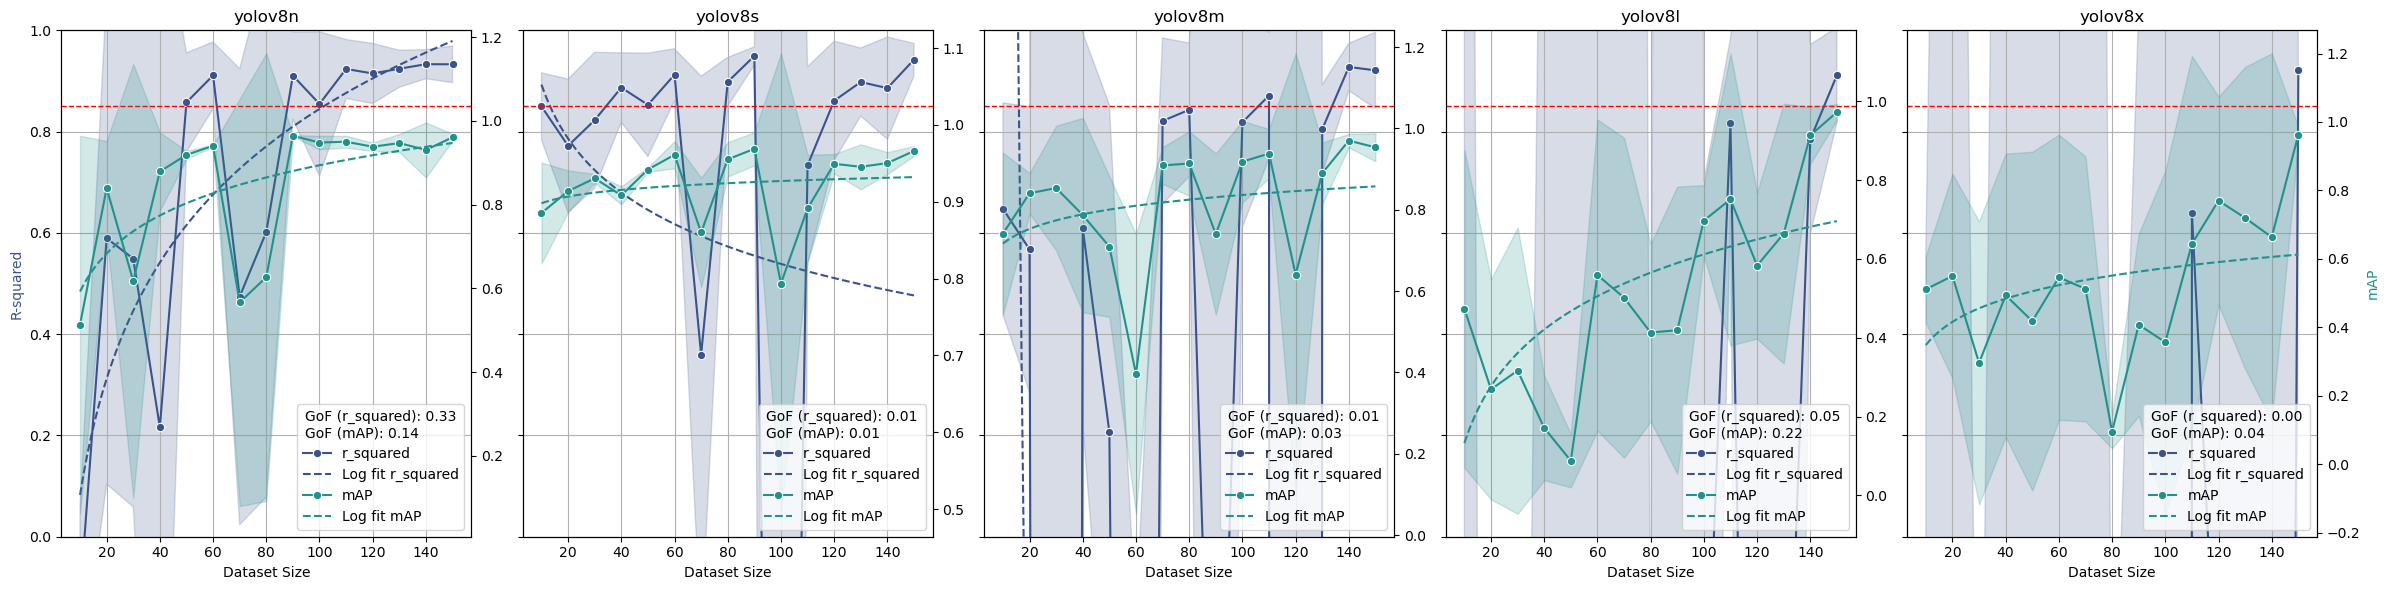

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define a logarithmic function for fitting
def log_func(x, a, b):
    return a * np.log(x) + b

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='r_squared',
        legend=False
    )
    
    # Fit a logarithmic model to r_squared vs dataset_size
    popt_r2, _ = curve_fit(log_func, model_data['dataset_size'], model_data['r_squared'])
    x_fit = np.linspace(model_data['dataset_size'].min(), model_data['dataset_size'].max(), 100)
    y_fit_r2 = log_func(x_fit, *popt_r2)
    ax.plot(x_fit, y_fit_r2, color=metric_colors['r_squared'], linestyle='--', label='Log fit r_squared')
    
    # Calculate R^2 for r_squared
    r2_r2 = r2_score(model_data['r_squared'], log_func(model_data['dataset_size'], *popt_r2))
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit a logarithmic model to ap_iou_50 vs dataset_size
    popt_ap, _ = curve_fit(log_func, model_data['dataset_size'], model_data['ap_iou_50'])
    y_fit_ap = log_func(x_fit, *popt_ap)
    ax2.plot(x_fit, y_fit_ap, color=metric_colors['ap_iou_50'], linestyle='--', label='Log fit mAP')
    
    # Calculate R^2 for ap_iou_50
    r2_ap = r2_score(model_data['ap_iou_50'], log_func(model_data['dataset_size'], *popt_ap))
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    combined_title = f'GoF (r_squared): {r2_r2:.2f}\nGoF (mAP): {r2_ap:.2f}'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolov8.pdf', format='pdf')
# plt.show()

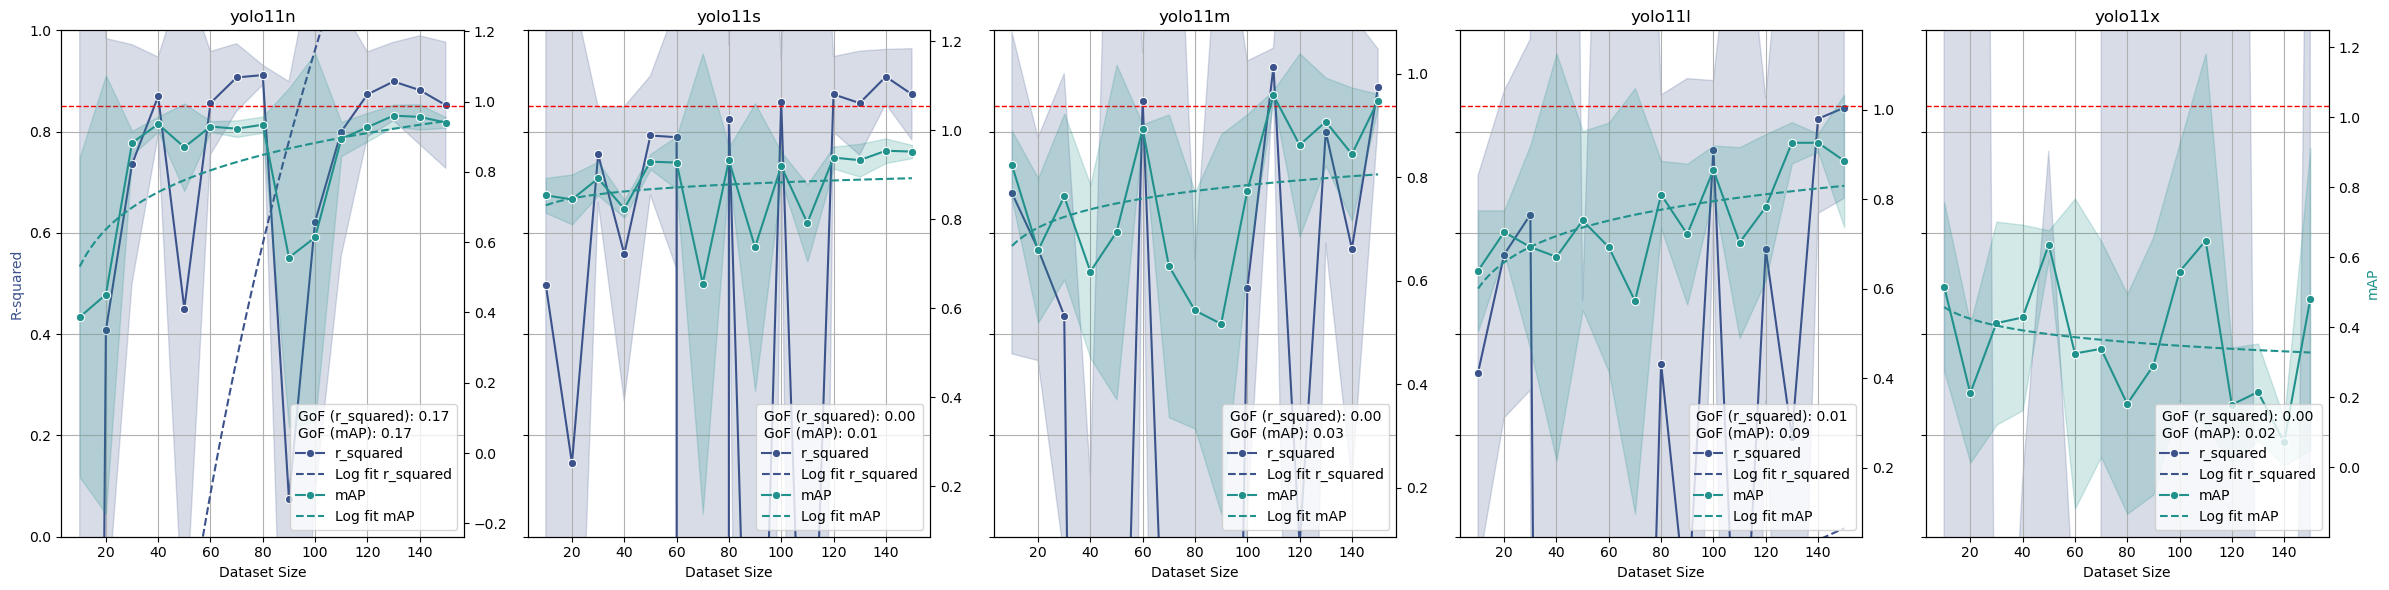

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define a logarithmic function for fitting
def log_func(x, a, b):
    return a * np.log(x) + b

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='r_squared',
        legend=False
    )
    
    # Fit a logarithmic model to r_squared vs dataset_size
    popt_r2, _ = curve_fit(log_func, model_data['dataset_size'], model_data['r_squared'])
    x_fit = np.linspace(model_data['dataset_size'].min(), model_data['dataset_size'].max(), 100)
    y_fit_r2 = log_func(x_fit, *popt_r2)
    ax.plot(x_fit, y_fit_r2, color=metric_colors['r_squared'], linestyle='--', label='Log fit r_squared')
    
    # Calculate R^2 for r_squared
    r2_r2 = r2_score(model_data['r_squared'], log_func(model_data['dataset_size'], *popt_r2))
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit a logarithmic model to ap_iou_50 vs dataset_size
    popt_ap, _ = curve_fit(log_func, model_data['dataset_size'], model_data['ap_iou_50'])
    y_fit_ap = log_func(x_fit, *popt_ap)
    ax2.plot(x_fit, y_fit_ap, color=metric_colors['ap_iou_50'], linestyle='--', label='Log fit mAP')
    
    # Calculate R^2 for ap_iou_50
    r2_ap = r2_score(model_data['ap_iou_50'], log_func(model_data['dataset_size'], *popt_ap))
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    combined_title = f'GoF (r_squared): {r2_r2:.2f}\nGoF (mAP): {r2_ap:.2f}'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolo11.pdf', format='pdf')
# plt.show()

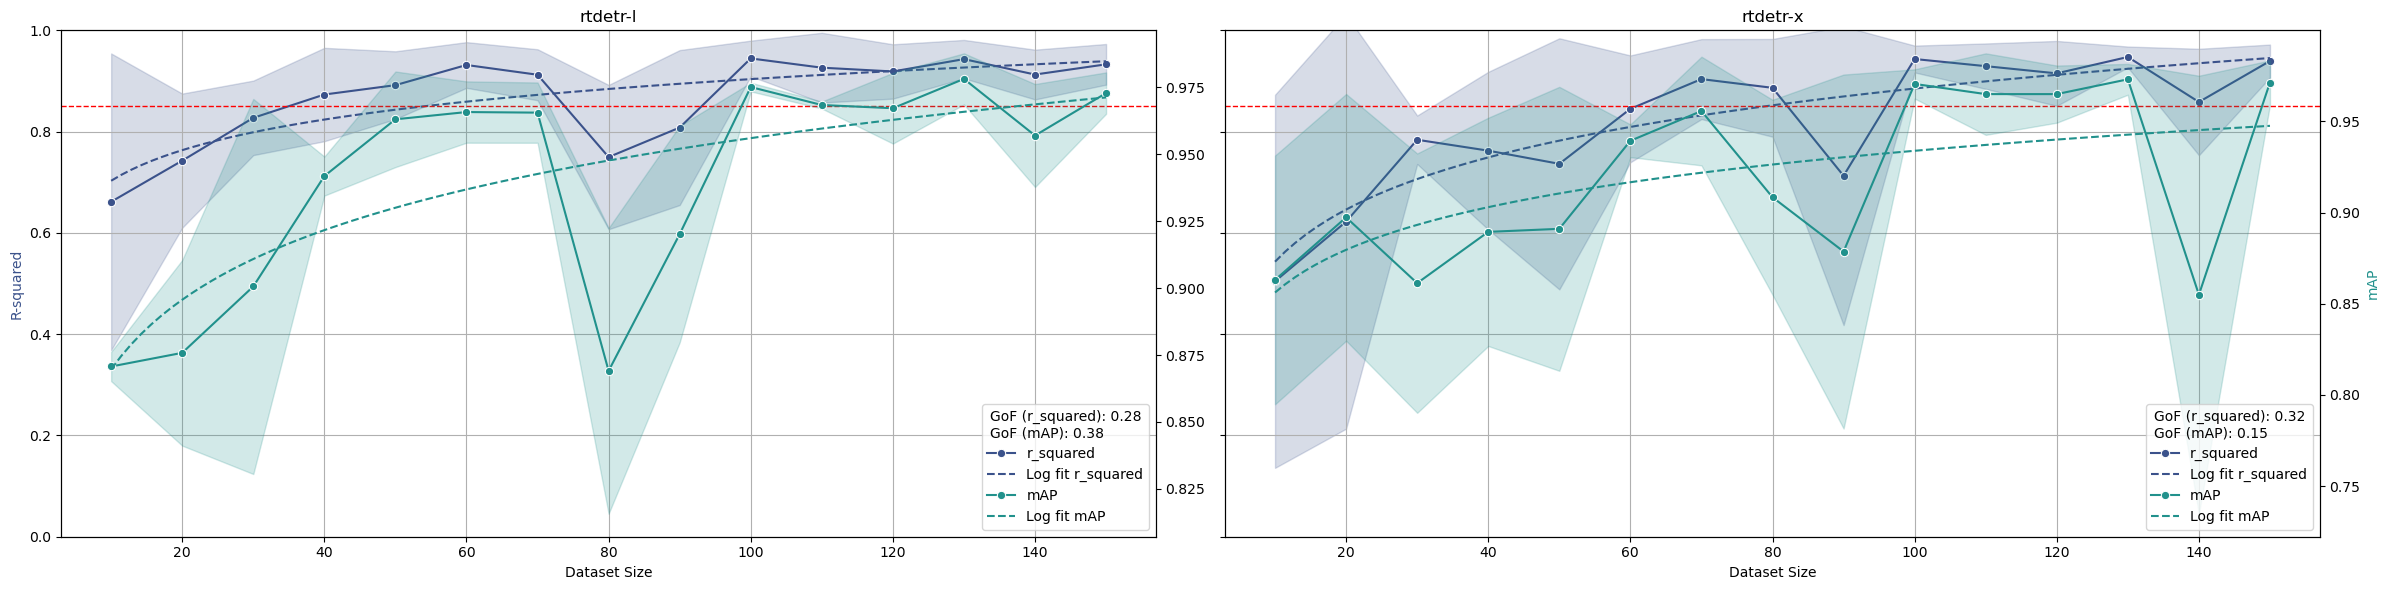

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['rtdetr-l', 'rtdetr-x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define a logarithmic function for fitting
def log_func(x, a, b):
    return a * np.log(x) + b

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='r_squared',
        legend=False
    )
    
    # Fit a logarithmic model to r_squared vs dataset_size
    popt_r2, _ = curve_fit(log_func, model_data['dataset_size'], model_data['r_squared'])
    x_fit = np.linspace(model_data['dataset_size'].min(), model_data['dataset_size'].max(), 100)
    y_fit_r2 = log_func(x_fit, *popt_r2)
    ax.plot(x_fit, y_fit_r2, color=metric_colors['r_squared'], linestyle='--', label='Log fit r_squared')
    
    # Calculate R^2 for r_squared
    r2_r2 = r2_score(model_data['r_squared'], log_func(model_data['dataset_size'], *popt_r2))
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit a logarithmic model to ap_iou_50 vs dataset_size
    popt_ap, _ = curve_fit(log_func, model_data['dataset_size'], model_data['ap_iou_50'])
    y_fit_ap = log_func(x_fit, *popt_ap)
    ax2.plot(x_fit, y_fit_ap, color=metric_colors['ap_iou_50'], linestyle='--', label='Log fit mAP')
    
    # Calculate R^2 for ap_iou_50
    r2_ap = r2_score(model_data['ap_iou_50'], log_func(model_data['dataset_size'], *popt_ap))
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    combined_title = f'GoF (r_squared): {r2_r2:.2f}\nGoF (mAP): {r2_ap:.2f}'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R-squared', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_rtdetr.pdf', format='pdf')
# plt.show()

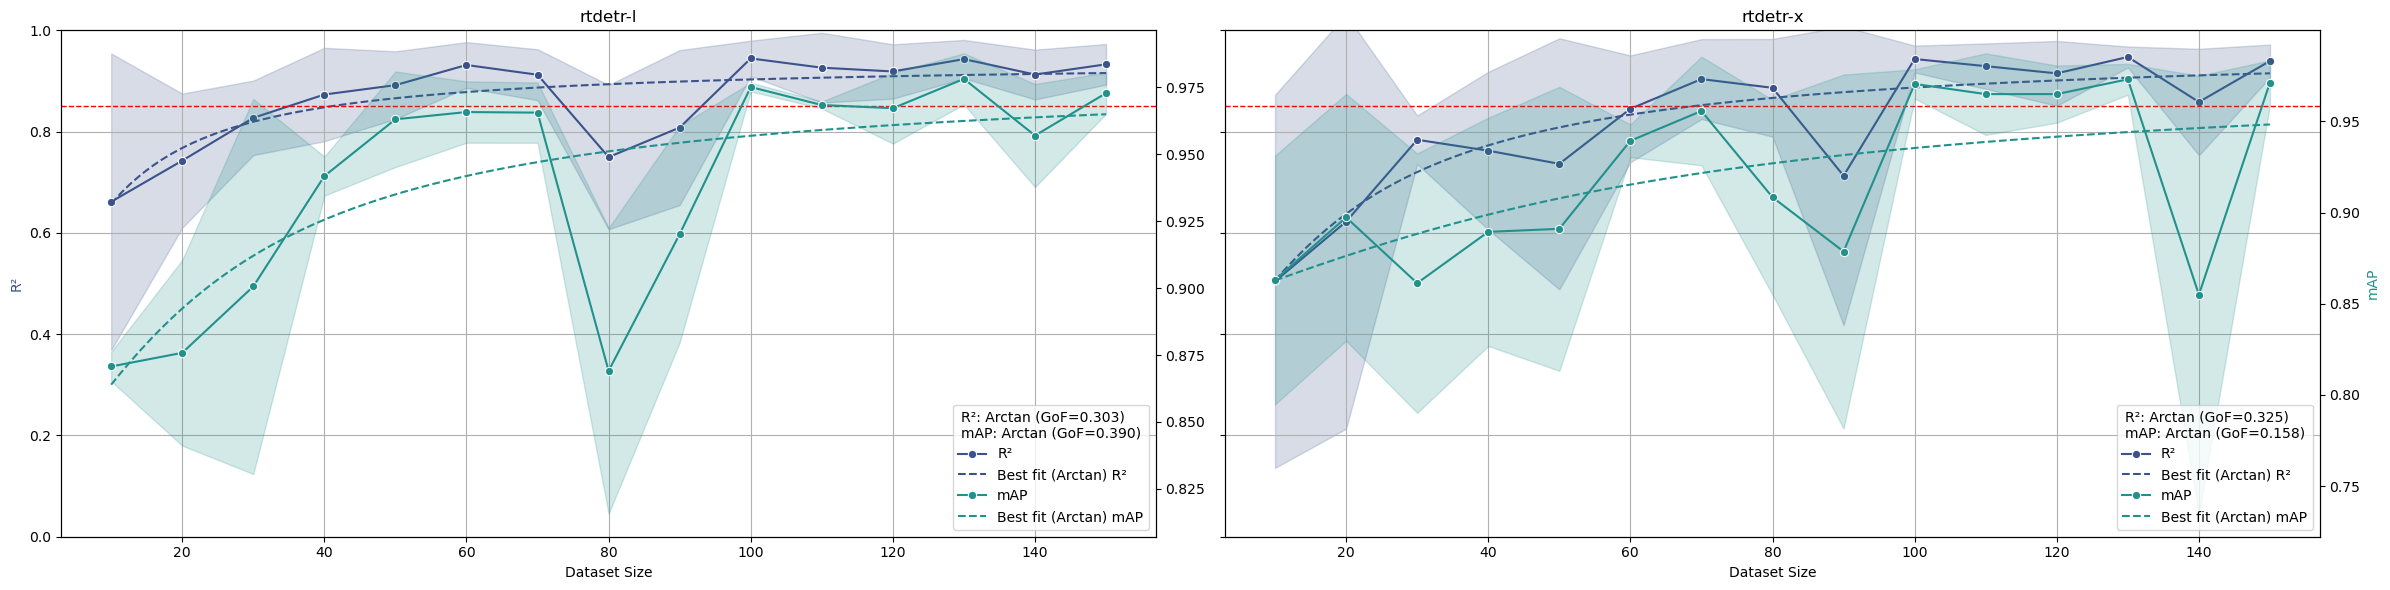

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['rtdetr-l', 'rtdetr-x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for r_squared vs dataset_size
    x_data = model_data['dataset_size']
    y_data = model_data['r_squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for r_squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['r_squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50 vs dataset_size
    y_data_ap = model_data['ap_iou_50']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['ap_iou_50'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R²', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_rtdetr.pdf', format='pdf')
# plt.show()

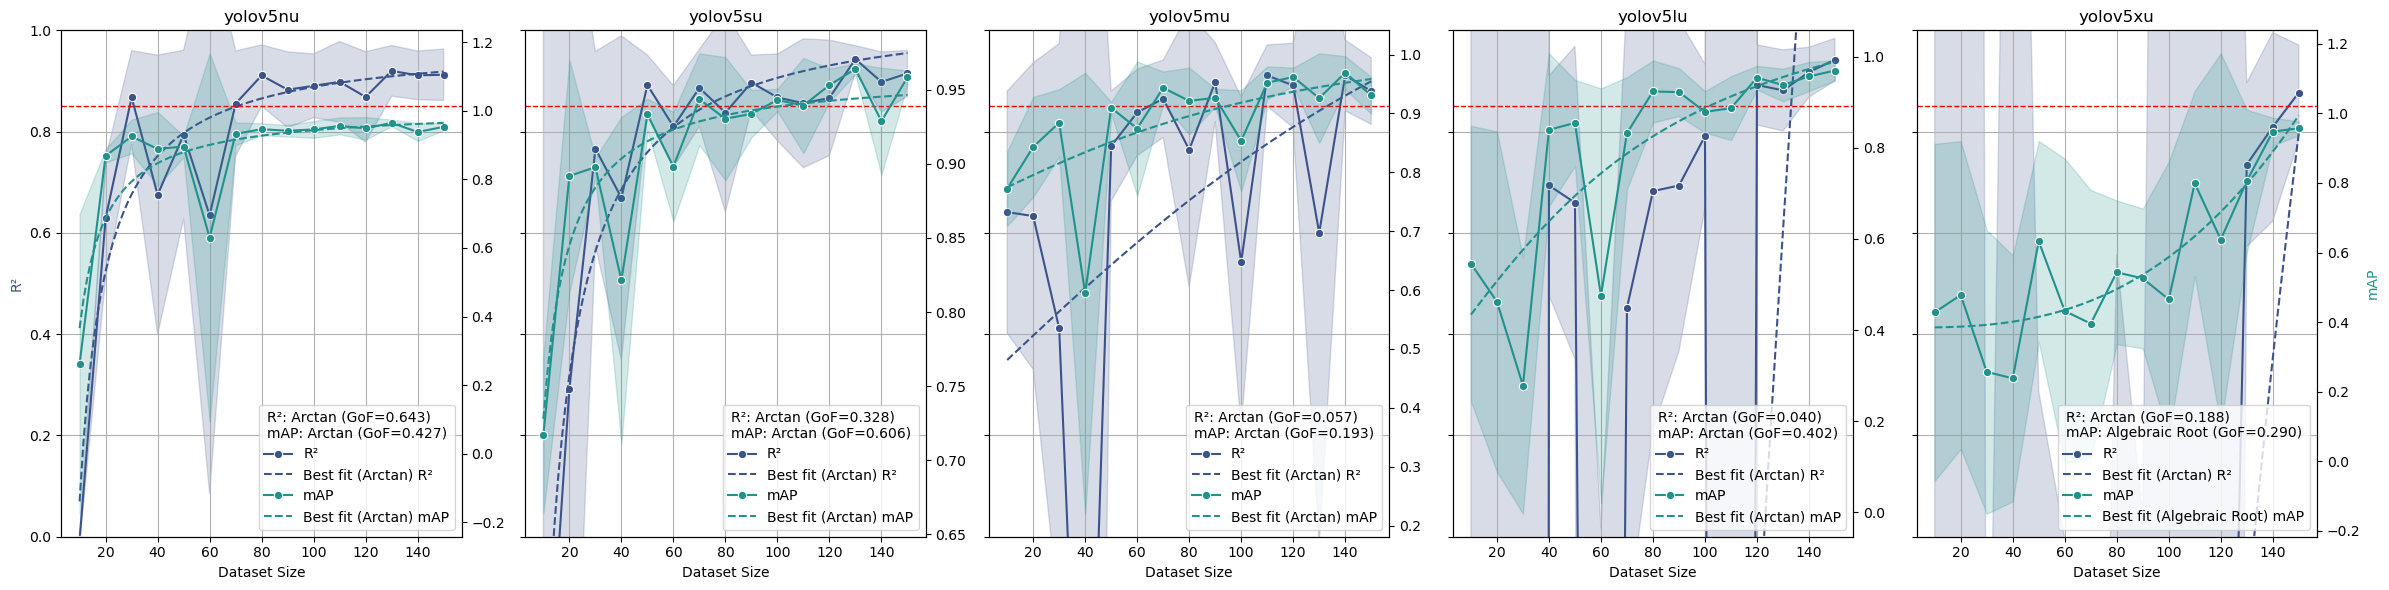

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for r_squared vs dataset_size
    x_data = model_data['dataset_size']
    y_data = model_data['r_squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for r_squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['r_squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50 vs dataset_size
    y_data_ap = model_data['ap_iou_50']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['ap_iou_50'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R²', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolov5.pdf', format='pdf')
# plt.show()

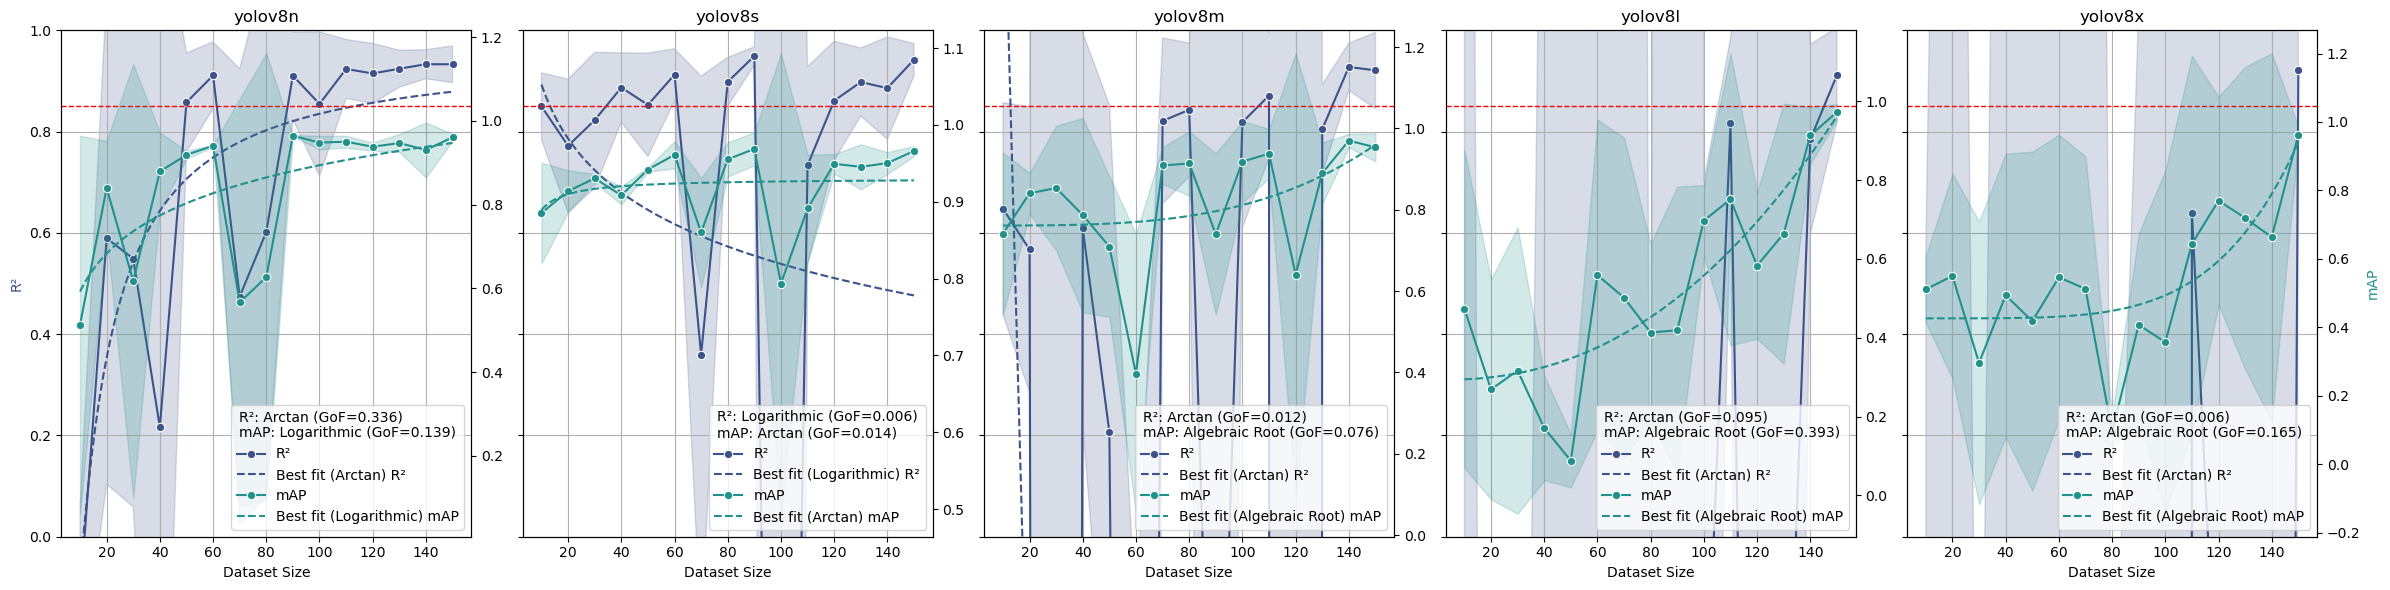

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for r_squared vs dataset_size
    x_data = model_data['dataset_size']
    y_data = model_data['r_squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for r_squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['r_squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50 vs dataset_size
    y_data_ap = model_data['ap_iou_50']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['ap_iou_50'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R²', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolov8.pdf', format='pdf')
# plt.show()

/tmp/ipykernel_38886/793437927.py:103: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)


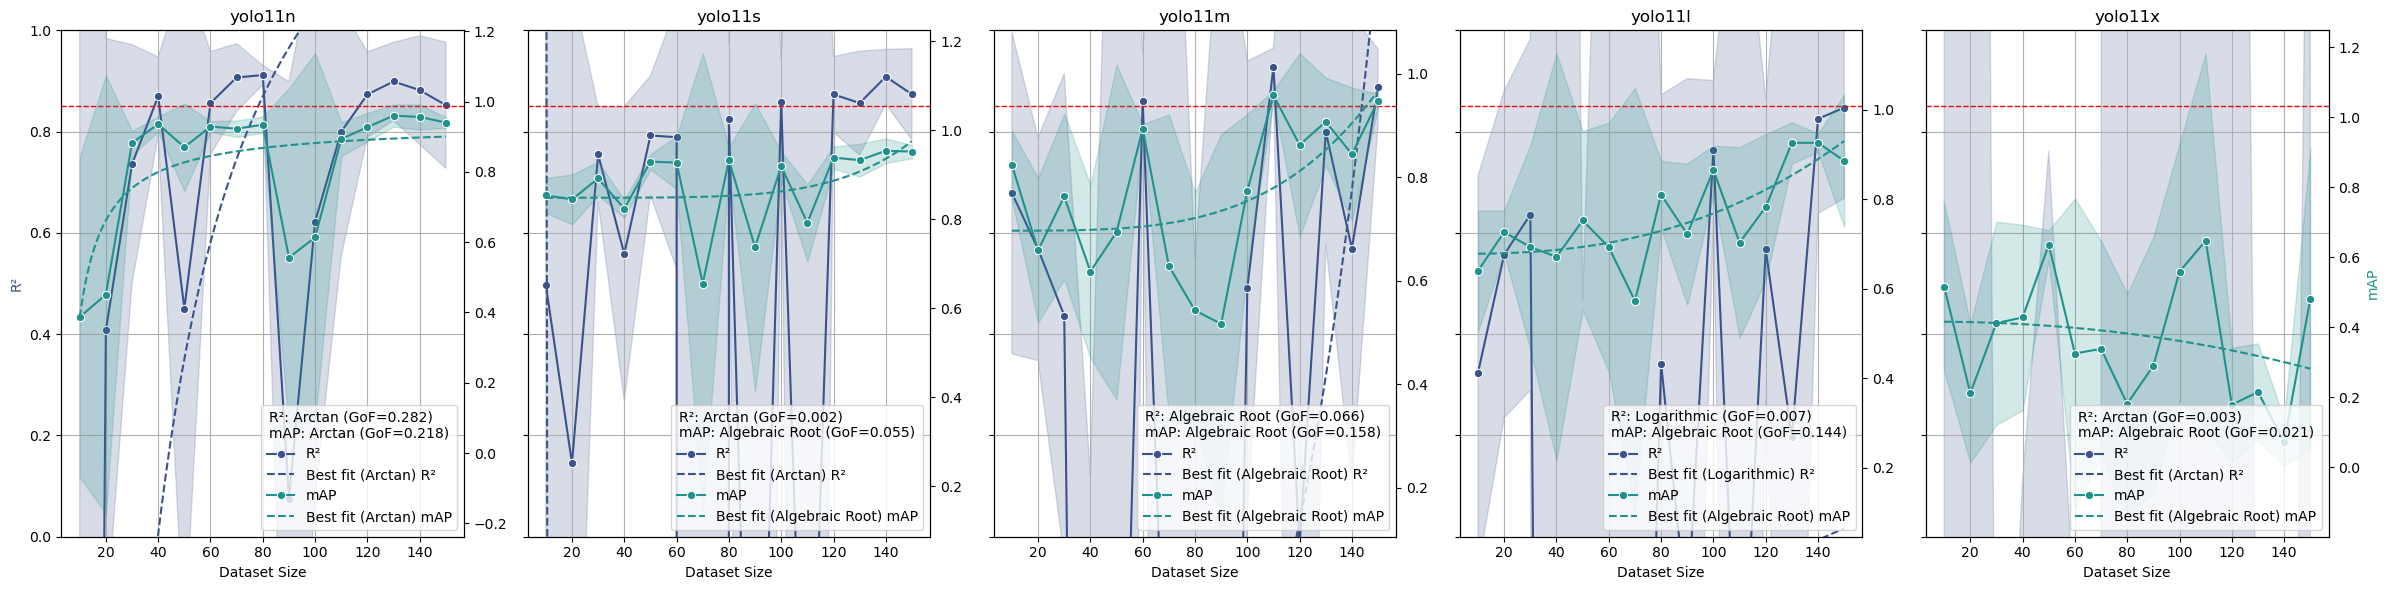

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

models = ['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x']

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Select out_domain as no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']

# Filter the DataFrame to include the specified models
filtered_df = filtered_df[filtered_df['model'].isin(models)]

# Group by 'dataset', 'model', and 'dataset_size' and select the observation with the highest 'r_squared' value
filtered_df = filtered_df.loc[filtered_df.groupby(['dataset', 'model', 'dataset_size'])['r_squared'].idxmax()]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors for each metric using the Viridis colormap
viridis = sns.color_palette("viridis", 3)
metric_colors = {'r_squared': viridis[0], 'ap_iou_50': viridis[1]}

# Define fitting functions
def log_func(x, a, b):
    return a * np.log(x) + b

def arctan_func(x, a, b, c):
    return a * np.arctan(b * x) + c

def root_func(x, a, b, c):
    return a * np.power(x, 1/b) + c

# Create subplots
fig, axes = plt.subplots(1, len(models), figsize=(24, 6), sharey=True)

for i, (ax, model) in enumerate(zip(axes, models)):
    # Filter to single model
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Plot r_squared
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['r_squared'],
        ax=ax,
        label='R²',
        legend=False
    )
    
    # Fit functions for r_squared vs dataset_size
    x_data = model_data['dataset_size']
    y_data = model_data['r_squared']
    x_fit = np.linspace(x_data.min(), x_data.max(), 100)
    
    # Initialize variables to track best fit
    best_r2_fit = None
    best_r2_score = -np.inf
    best_r2_name = ""
    
    # Try logarithmic fit
    try:
        popt_log, _ = curve_fit(log_func, x_data, y_data)
        y_fit_log = log_func(x_fit, *popt_log)
        r2_log = r2_score(y_data, log_func(x_data, *popt_log))
        if r2_log > best_r2_score:
            best_r2_fit = y_fit_log
            best_r2_score = r2_log
            best_r2_name = "Logarithmic"
    except:
        r2_log = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan, _ = curve_fit(arctan_func, x_data, y_data)
        y_fit_arctan = arctan_func(x_fit, *popt_arctan)
        r2_arctan = r2_score(y_data, arctan_func(x_data, *popt_arctan))
        if r2_arctan > best_r2_score:
            best_r2_fit = y_fit_arctan
            best_r2_score = r2_arctan
            best_r2_name = "Arctan"
    except:
        r2_arctan = -np.inf
    
    # Try root fit
    try:
        p0 = [1, 2, 0]  # Initial parameter guess
        popt_root, _ = curve_fit(root_func, x_data, y_data, p0=p0)
        y_fit_root = root_func(x_fit, *popt_root)
        r2_root = r2_score(y_data, root_func(x_data, *popt_root))
        if r2_root > best_r2_score:
            best_r2_fit = y_fit_root
            best_r2_score = r2_root
            best_r2_name = "Algebraic Root"
    except:
        r2_root = -np.inf
    
    # Plot the best fit for r_squared
    ax.plot(x_fit, best_r2_fit, color=metric_colors['r_squared'], linestyle='--', 
            label=f'Best fit ({best_r2_name}) R²')
    
    # Create a twin Axes sharing the x-axis
    ax2 = ax.twinx()
    
    # Plot ap_iou_50
    sns.lineplot(
        x='dataset_size', 
        y='ap_iou_50', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o', 
        color=metric_colors['ap_iou_50'],
        ax=ax2,
        label='mAP',
        legend=False
    )
    
    # Fit functions for ap_iou_50 vs dataset_size
    y_data_ap = model_data['ap_iou_50']
    
    # Initialize variables to track best fit
    best_ap_fit = None
    best_ap_score = -np.inf
    best_ap_name = ""
    
    # Try logarithmic fit
    try:
        popt_log_ap, _ = curve_fit(log_func, x_data, y_data_ap)
        y_fit_log_ap = log_func(x_fit, *popt_log_ap)
        r2_log_ap = r2_score(y_data_ap, log_func(x_data, *popt_log_ap))
        if r2_log_ap > best_ap_score:
            best_ap_fit = y_fit_log_ap
            best_ap_score = r2_log_ap
            best_ap_name = "Logarithmic"
    except:
        r2_log_ap = -np.inf
    
    # Try arctan fit
    try:
        popt_arctan_ap, _ = curve_fit(arctan_func, x_data, y_data_ap)
        y_fit_arctan_ap = arctan_func(x_fit, *popt_arctan_ap)
        r2_arctan_ap = r2_score(y_data_ap, arctan_func(x_data, *popt_arctan_ap))
        if r2_arctan_ap > best_ap_score:
            best_ap_fit = y_fit_arctan_ap
            best_ap_score = r2_arctan_ap
            best_ap_name = "Arctan"
    except:
        r2_arctan_ap = -np.inf
    
    # Try root fit
    try:
        popt_root_ap, _ = curve_fit(root_func, x_data, y_data_ap, p0=[1, 2, 0])
        y_fit_root_ap = root_func(x_fit, *popt_root_ap)
        r2_root_ap = r2_score(y_data_ap, root_func(x_data, *popt_root_ap))
        if r2_root_ap > best_ap_score:
            best_ap_fit = y_fit_root_ap
            best_ap_score = r2_root_ap
            best_ap_name = "Algebraic Root"
    except:
        r2_root_ap = -np.inf
    
    # Plot the best fit for ap_iou_50
    ax2.plot(x_fit, best_ap_fit, color=metric_colors['ap_iou_50'], linestyle='--', 
             label=f'Best fit ({best_ap_name}) mAP')
    
    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    combined_lines = lines + lines2
    combined_labels = labels + labels2
    
    # Include best fit function name and R-squared in the legend title
    combined_title = f'R²: {best_r2_name} (GoF={best_r2_score:.3f})\nmAP: {best_ap_name} (GoF={best_ap_score:.3f})'
    ax2.legend(combined_lines, combined_labels, title=combined_title, loc='lower right')
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{model}')
    ax.set_xlabel('Dataset Size')
    if i == 0:
        ax.set_ylabel('R²', color=metric_colors['r_squared'])
    else:
        ax.set_ylabel('')
    ax.grid(True)
    
    if i == len(models) - 1:
        ax2.set_ylabel('mAP', color=metric_colors['ap_iou_50'])
    else:
        ax2.set_ylabel('')
    ax2.grid(False)

plt.tight_layout()

# Save as PDF
plt.savefig('MDPI_template/Plots/r2_ap_vs_dataset_size_yolo11.pdf', format='pdf')
# plt.show()